# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')  #completa el código
usage = pd.read_csv('/datasets/usage.csv') #completa el código

In [3]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print(users.isna().sum()) # Cantidad de valores nulos)
print()
print(users.isna().mean()) # Proporción de valores nulos)

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
# cantidad de nulos para usage
print(usage.isna().sum()) # Cantidad de valores nulos)
print()
print(usage.isna().mean()) # Proporción de valores nulos)

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
- ### Respuestas:
    - las columnas que tienen valores nulos en el "df users"  son: "city", "churn_date"
    - las columnas que tiene valores nulos en el "df usuage" son: "date","duration","lenght"
  
- Indica qué harías: ¿imputar, eliminar, ignorar?

- ### users
   - para los valores faltantes en "city" investigaria e imputaria o dejaria como nulos porque el 11% de los datos son nulos
   - para los valores faltantes en "churn_date" eliminaria la columna dado que los valores faltantes superan el 80% de los datos en la columna.
  ### usuge
    - para los valores faltantes en "date" es un caso simple de imputacion dado que el 0,125% es el porcentaje/proporcion de valores faltantes
    - para los valores faltantes en "duration" se debe investigar para imputar o dejar como nulos dado que los valores nulos corresponden al 55% de los datos en la columna
    - para los valors faltantes en "length" se debe investigar para imputar o dejar como nulos dado que los valores nulos corresponden al 44% de los datos en la columna


### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` tiene 4,000 identificadores únicos, con valores entre 10,000 y 13,999. Al ser un identificador, sus estadísticas descriptivas no tienen una interpretación relevante para el análisis.
- La columna `age` presenta edades entre 32 y 79 años para la mayoría de los registros, pero se observa un valor mínimo de -999, que no es una edad válida y probablemente representa un dato faltante o erróneo. Este valor puede afectar el promedio, que es de 33.74 años, mientras que la mediana es de 47 años. Por ello, será necesario investigar y tratar estos valores antes de realizar análisis posteriores sobre la edad. 

In [13]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` es simplemente un identificador del registro, por lo que sus estadísticas descriptivas no tienen una interpretación analítica relevante y `user_id` La columna id contiene 40,000 identificadores, con valores entre 1 y 40,000. Al ser un identificador único de cada registro, sus estadísticas descriptivas no aportan información relevante para el análisis. sin embargo `user_id` es un identificador que nos permite relacionar usage con users
- Las columnas `duration` la media es 5,20, la mediana 3,50 y los valores van de 0 a 120. Para `length`, la media es 52,13, la mediana 50 y los valores van de 0 a 1.490.

In [14]:
# explorar columnas categóricas de users
columnas_user = users[['city', 'plan']].describe()
columnas_user

,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


- La columna `city` tiene 3531 registros con 7 valores unicos, el valor mas repetido es "Bogotá" con 808 repeticiones.
- La columna `plan` tiene 4000 registros con 2 valores unicos, el plan que mas frecuencia tiene es el "basico" con 2595 veces.

In [15]:
# explorar columna categórica de usage
usage['type'].describe() # completa el código

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type` tiene 40000 registros con 2 valores unicos y el valor que mas se repites es "text".


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
    - En la columna age se encontró el valor -999, que no corresponde a una edad válida y puede ser un valor sentinel utilizado para representar información desconocida o no disponible.
    
- ¿Qué acción tomarías?
    - Revisaría cuántos registros tienen el valor -999 en age y confirmaría qué representa antes de modificarlo. Si corresponde a un sentinel, lo reemplazaría por NaN para que no afecte los análisis estadísticos posteriores. 

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN
...,...,...,...,...,...,...,...,...
3995,13995,Ana,Lopez,60,Medellín,2024-12-29 21:42:48.342085520,Basico,NaN
3996,13996,Carlos,Ramirez,24,Medellín,2024-12-30 04:17:06.256564144,Premium,NaN
3997,13997,Ana,Lopez,58,Bogotá,2024-12-30 10:51:24.171042768,Premium,NaN
3998,13998,Mariana,Lopez,57,Bogotá,2024-12-30 17:25:42.085521392,Basico,NaN


In [17]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors="coerce") # completa el código

In [18]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors="coerce") # completa el código

In [19]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts()


2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `reg_date` existen 40 registros del año 2026, sin embargo esto debe ser un error dado que las indicaciones nos informan que los datos existentes son hasta el añp 2024.

In [20]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts()

2024.0    39950
Name: date, dtype: int64

En `date`, los registros son del año 2024 es decir que los registros estan en la fecha correcta, sin embargo de acuerdo al total de registros hay 50 datos faltantes

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
    - Si en "users" como se informo anteriormente existen 40 registros del año 2026, sin embargo esto debe ser un error dado que las indicaciones nos informan que los datos existentes son hasta el añp 2024.
- ¿Qué harías con ellas?
- es un caso simple de imputacion dado que el 0,125% es el porcentaje/proporcion de valores faltantes

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [21]:

# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)


# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [22]:
# Reemplazar ? por NA en city
users["city"] = users["city"].replace("?", np.nan)

# Verificar cambios
users["city"].value_counts(dropna=True)

Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [23]:
###
users[users['reg_date'].dt.year == 2026]

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
40,10040,Ana,Garcia,59.0,Medellín,2026-05-10,Basico,NaN
56,10056,Luis,Garcia,29.0,CDMX,2026-05-10,Basico,"1,72187E+18"
60,10060,Carlos,Torres,45.0,CDMX,2026-05-10,Basico,NaN
70,10070,Mariana,Gomez,50.0,CDMX,2026-05-10,Premium,NaN
248,10248,Sofia,Garcia,20.0,Medellín,2026-05-10,Premium,"1,72506E+18"
320,10320,Sofia,Garcia,74.0,GDL,2026-05-10,Premium,NaN
326,10326,Mariana,Torres,51.0,Medellín,2026-05-10,Premium,NaN
505,10505,Luis,Garcia,75.0,CDMX,2026-05-10,Basico,NaN
527,10527,Carlos,Torres,71.0,MTY,2026-05-10,Basico,NaN
646,10646,Luis,Ramirez,50.0,CDMX,2026-05-10,Premium,NaN


In [24]:
###
(users['reg_date'].dt.year == 2026).sum()

40

In [25]:
# Marcar fechas futuras como NA para reg_date

users.loc[users['reg_date'].dt.year == 2026, 'reg_date'] = np.nan

# Verificar cambios
users['reg_date'].dt.year.value_counts()

2024.0    1330
2023.0    1316
2022.0    1314
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [26]:
# Verificación MAR en usage (Missing At Random) para duration
usage[usage['duration'].isna()].groupby('type').size()

usage.groupby('type')['duration'].count()

type
call    17908
text       16
Name: duration, dtype: int64

In [27]:
# Verificación MAR en usage (Missing At Random) para length
usage[usage['length'].isna()].groupby('type').size()

usage.groupby('type')['length'].count()

type
call       12
text    22092
Name: length, dtype: int64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length` están relacionados con la columna "type", por lo que se consideran MAR respecto a esta variable y se mantienen como nulos, es decir que `duration` está prácticamente disponible para los registros call, mientras que para text está prácticamente ausente.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [28]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg(
    total_mensajes=('is_text', 'sum'),
    total_llamadas=('is_call', 'sum'),
    total_minutos_llamadas=('duration', 'sum')).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,total_mensajes,total_llamadas,total_minutos_llamadas
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [29]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'total_mensajes': 'cant_mensajes',
    'total_llamadas': 'cant_llamadas',
    'total_minutos_llamadas': 'cant_minutos_llamada'
    })

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [30]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [31]:
# Resumen estadístico de las columnas numéricas
user_profile.describe()

,user_id,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,3999.000000,3999.000000,3999.000000
mean,11999.500000,48.122250,5.524381,4.478120,23.317054
std,1154.844867,17.690408,2.358416,2.144238,18.168095
min,10000.000000,18.000000,0.000000,0.000000,0.000000
25%,10999.750000,33.000000,4.000000,3.000000,11.120000
50%,11999.500000,47.000000,5.000000,4.000000,19.780000
75%,12999.250000,63.000000,7.000000,6.000000,31.415000
max,13999.000000,79.000000,17.000000,15.000000,155.690000


In [33]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

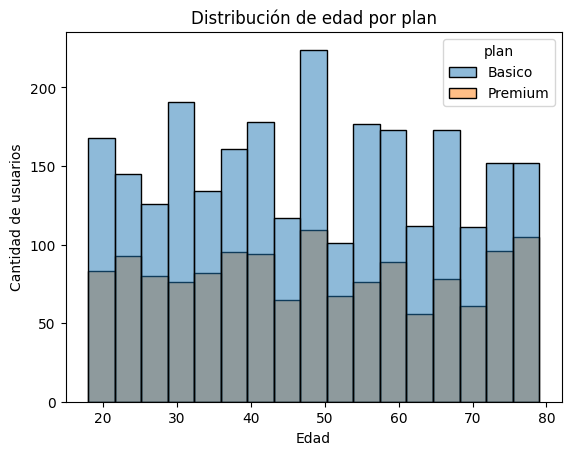

In [43]:
# Histograma para visualizar la edad (age)
sns.histplot(
    data=user_profile,
    x='age',
    hue='plan'
)

plt.title('Distribución de edad por plan')
plt.xlabel('Edad')
plt.ylabel('Cantidad de usuarios')

plt.show()

💡Insights: 
- Distribución de la edad de los usuarios se encuentra aproximadamente entre los 18 y 79 años. No se observa un patrón claro que diferencie los planes Básico y Premium según la edad, ya que ambos están distribuidos a lo largo del rango. La distribución es relativamente irregular y no presenta un sesgo evidente.

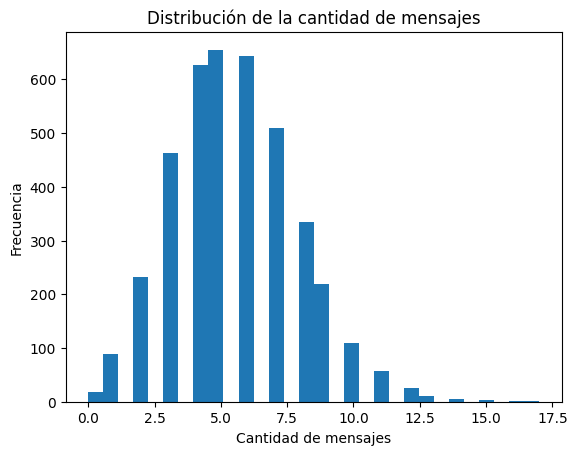

In [45]:
# Histograma para visualizar la cant_mensajes
plt.hist(user_profile['cant_mensajes'], bins=30)

plt.title('Distribución de la cantidad de mensajes')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Frecuencia')

plt.show()

💡Insights: 
- la cantidad de mensajes presenta principalmente entre 3 y 8 mensajes, con una mayor frecuencia alrededor de 5 mensajes.
- la mayoría de los usuarios envía una cantidad moderada de mensajes. A medida que aumenta la cantidad de mensajes, la frecuencia disminuye

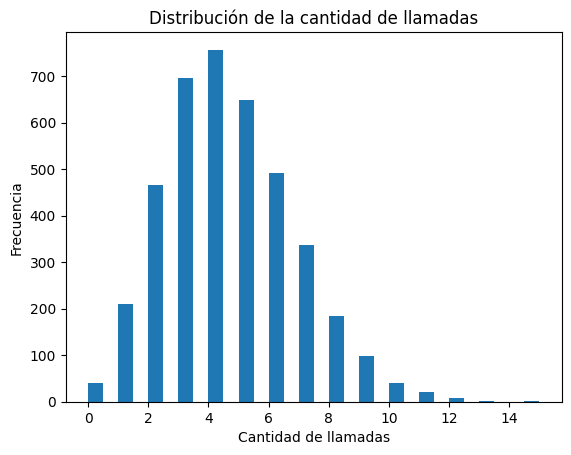

In [42]:
# Histograma para visualizar la cant_llamadas
plt.hist(user_profile['cant_llamadas'], bins=30)

plt.title('Distribución de la cantidad de llamadas')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')

plt.show()

💡Insights: 
- La mayoría de los clientes realiza exactamente 4 llamadas, representando el punto más alto del gráfico con más de 750 registros.
- Muy pocos usuarios realizan 0 llamadas o más de 10 llamadas.

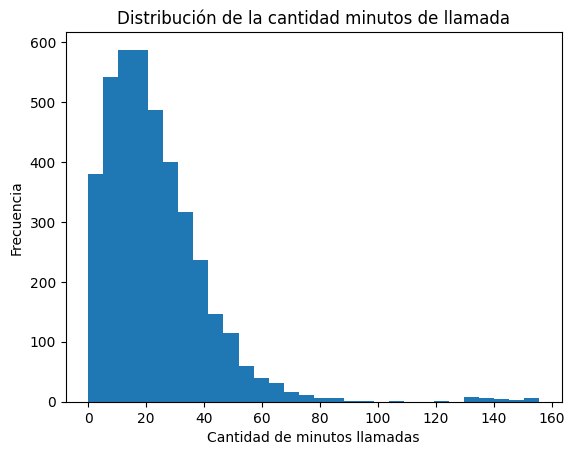

In [46]:
# Histograma para visualizar la cant_minutos_llamada
plt.hist(user_profile['cant_minutos_llamada'], bins=30)

plt.title('Distribución de la cantidad minutos de llamada')
plt.xlabel('Cantidad de minutos llamadas')
plt.ylabel('Frecuencia')

plt.show()

💡Insights: 
- La mayor concentración de usuarios habla entre 10 y 20 minutos, alcanzando el punto más alto del gráfico con casi 600 registros.
- La cantidad de usuarios cae rápidamente a medida que aumentan los minutos, mostrando que las llamadas de más de 60 minutos son poco frecuentes.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

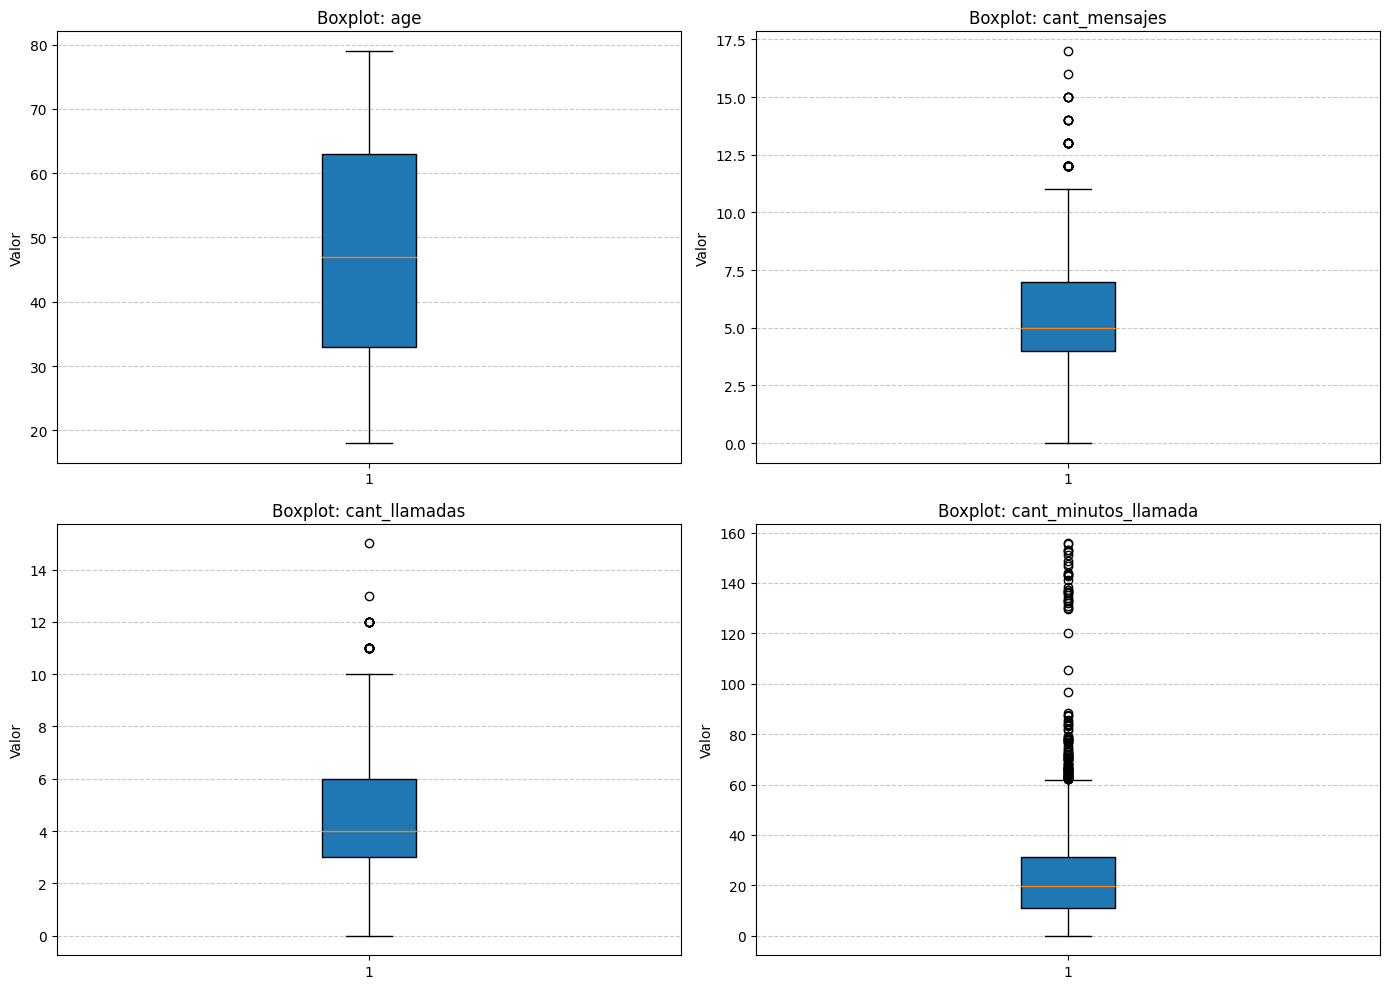

In [52]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
plt.figure(figsize=(14, 10))
for i, col in enumerate(columnas_numericas, 1):
    plt.subplot(2, 2, i)
    plt.boxplot(user_profile[col].dropna(), vert=True, patch_artist=True)
    plt.title(f"Boxplot: {col}")
    plt.ylabel("Valor")
    plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

- Age: No presenta outliers. La distribución se encuentra acotada entre los 18 y aproximadamente 79 años, sin puntos por fuera de los bigotes.

- cant_mensajes: Presenta outliers superiores. Los datos están concentrados por debajo de 11 mensajes, pero existen valores atípicos que van desde los 12 hasta los 17 mensajes.

- cant_llamadas: Presenta outliers superiores. La mayor parte de la distribución se ubica por debajo de las 10 llamadas, observándose puntos atípicos aislados en 11, 12, 13 y 15 llamadas.

- cant_minutos_llamada: Presenta un volumen elevado de outliers superiores. El límite superior del bigote se ubica cerca de los 60 minutos, pero hay una gran densidad de valores atípicos que se extienden desde los 62 hasta casi los 160 minutos.

In [56]:
# Calcular límites con el método IQR
columnas_limites = ["cant_mensajes", "cant_llamadas", "cant_minutos_llamada"]

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_superior = Q3 + 1.5 * IQR  

    outliers = user_profile[user_profile[col] > limite_superior]

    print(f"Análisis de IQR: {col} ")
    print(f"Q1: {Q1:.2f} | Q3: {Q3:.2f} | IQR: {IQR:.2f}")
    print(f"Límite Superior: {limite_superior:.2f}")

Análisis de IQR: cant_mensajes 
Q1: 4.00 | Q3: 7.00 | IQR: 3.00
Límite Superior: 11.50
Análisis de IQR: cant_llamadas 
Q1: 3.00 | Q3: 6.00 | IQR: 3.00
Límite Superior: 10.50
Análisis de IQR: cant_minutos_llamada 
Q1: 11.12 | Q3: 31.41 | IQR: 20.30
Límite Superior: 61.86


In [57]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
- `respuesta:` Con un percentil 75% en 7 y un máximo de 17 mensajes, el valor extremo es pequeño y representa a clientes con mayor uso del servicio; eliminarlos afectaria el comportamiento real de los usuarios activos.
- cant_llamadas: mantener o no outliers, porqué?
- 'Respuesta: ' La media 4.48 y la mediana 4.00 son muy similares, y el valor máximo de 15 llamadas no es un error de medición, sino los clientes que hacen más llamadas.
- cant_minutos_llamada: mantener o no outliers, porqué?
- Respuesta: Aunque el valor máximo (155.69 min) se aleja bastante de la mediana (19.78 min), estos datos reflejan a los usuarios activos que generan un impacto real, por lo que eliminarlos sesgaría el análisis.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [65]:
# Crear columna grupo_uso
condiciones = [
    (user_profile["cant_llamadas"] < 5) & (user_profile["cant_mensajes"] < 5),
    (user_profile["cant_llamadas"] < 10) & (user_profile["cant_mensajes"] < 10),
]

# Definir las etiquetas 
opciones = ["Bajo uso", "Uso medio"]

user_profile["grupo_uso"] = np.select(condiciones, opciones, default="Alto uso")


In [66]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [67]:
# Crear columna grupo_edad

condiciones_edad = [
    user_profile["age"] < 30,
    user_profile["age"] < 60,
]

opciones_edad = ["Joven", "Adulto"]

user_profile["grupo_edad"] = np.select(
    condiciones_edad, opciones_edad, default="Adulto Mayor"
)


In [68]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

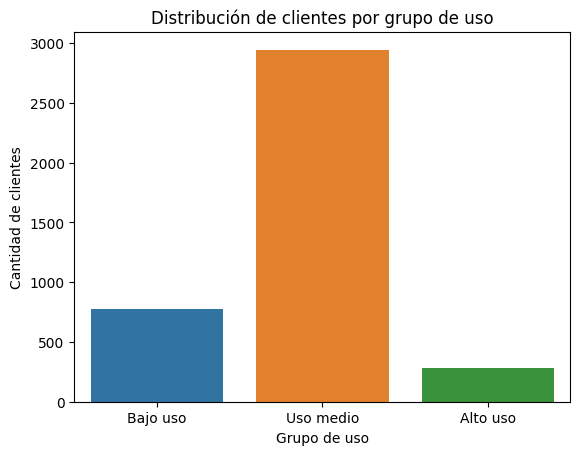

In [73]:
# Visualización de los segmentos por uso
sns.countplot(
    data=user_profile,
    x="grupo_uso",
    order=["Bajo uso", "Uso medio", "Alto uso"],
)
plt.title("Distribución de clientes por grupo de uso")
plt.xlabel("Grupo de uso")
plt.ylabel("Cantidad de clientes")
plt.show()

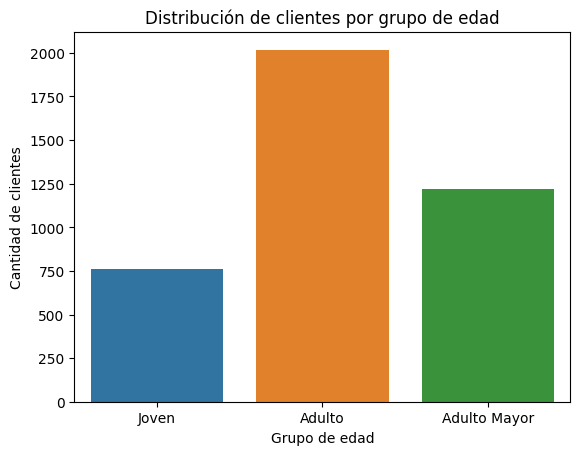

In [74]:
# Visualización de los segmentos por edad
sns.countplot(
    data=user_profile,
    x="grupo_edad",
    order=["Joven", "Adulto", "Adulto Mayor"],
)
plt.title("Distribución de clientes por grupo de edad")
plt.xlabel("Grupo de edad")
plt.ylabel("Cantidad de clientes")
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Se identificaron registros con datos faltantes o nulos en variables clave de perfilación y fechas de cancelación "churn_date", así como diferencias en los tipos de datos.
- Los problemas detectados en la información afectaban a un porcentaje menor de la muestra, por lo que tras el proceso de limpieza la base mantuvo un tamaño de 3,999 registros para el análisis.


🔍 **Segmentos por Edad**
- La mayor parte de la base de datos son en el segmento Adulto de 30-59 años, seguido por los Adultos Mayores 60 años y una proporción de Jóvenes menosres de 30 años.

📊 **Segmentos por Nivel de Uso**
- La mayoría de los usuarios se ubica en las categorías de Bajo uso y Uso medio, mientras que el segmento de Alto uso representa un pequeño porcentake pero importante de la base.


➡️ Esto sugiere que los clientes con mayor cantidad de minutos hablados y mensajes enviados son valiosos dado que representan la mayor oportunidad de monetización. Aunque son un grupo reducido en volumen de personas, consumen mas que los otros tipos de clientes, siendo ideales para enfocar ventas.


💡 **Recomendaciones**
- Crear un plan ajustado para el segmento de "Bajo uso" y "Adulto Mayor", centrado en una tarifa económica con un paquete estándar de minutos para evitar que cancelen el servicio
- Promocionar paquetes para jovenes con mayor carga de datos sobre consumo de voz, enfocandose a sus tendencias actuales.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`